<a href="https://colab.research.google.com/github/2303A52306/explai-ai/blob/main/Assignment5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from  sklearn.model_selection  import  train_test_split, GridSearchCV
from  sklearn.preprocessing  import  StandardScaler,  MinMaxScaler,  OneHotEncoder
from  sklearn.compose  import  ColumnTransformer
from sklearn.pipeline import Pipeline
from  sklearn.impute  import  SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [3]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree  import  DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm  import SVR


In [5]:
try:
    import xgboost as xgb
    has_xgb = True
except Exception:
    has_xgb = False


In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks


In [7]:
import shap

In [9]:
try:
   import lime
   from lime import lime_tabular
   has_lime = True
except Exception:
   has_lime = False


In [10]:
import seaborn as sns
sns.set(style='whitegrid')


In [11]:
DATA_PATH = "co_emissions.csv"

In [13]:
if not os.path.exists(DATA_PATH):
   print(f"{DATA_PATH} not found. Please upload it.")
else:
    print(f"Using data from {DATA_PATH}")
    df = pd.read_csv(DATA_PATH)
    print("Dataset loaded. Shape:", df.shape)
    display(df.head())


co_emissions.csv not found. Please upload it.


In [70]:
try:
   df_info = df.info()
except Exception:
   pass


co_emissions.csv not found. Please upload it.


In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your CSV (update the path/filename)
df = pd.read_csv("/content/Data (1).csv")
# look at the first few rows
print(df.head())
print(df.columns)


  Description         Name  year iso_code  population  gdp  cement_co2  \
0     Country  Afghanistan  1850      AFG   3752993.0  NaN         0.0   
1     Country  Afghanistan  1851      AFG   3767956.0  NaN         0.0   
2     Country  Afghanistan  1852      AFG   3783940.0  NaN         0.0   
3     Country  Afghanistan  1853      AFG   3800954.0  NaN         0.0   
4     Country  Afghanistan  1854      AFG   3818038.0  NaN         0.0   

   cement_co2_per_capita  co2  co2_growth_abs  ...  share_global_other_co2  \
0                    0.0  NaN             NaN  ...                     NaN   
1                    0.0  NaN             NaN  ...                     NaN   
2                    0.0  NaN             NaN  ...                     NaN   
3                    0.0  NaN             NaN  ...                     NaN   
4                    0.0  NaN             NaN  ...                     NaN   

   share_of_temperature_change_from_ghg  temperature_change_from_ch4  \
0             

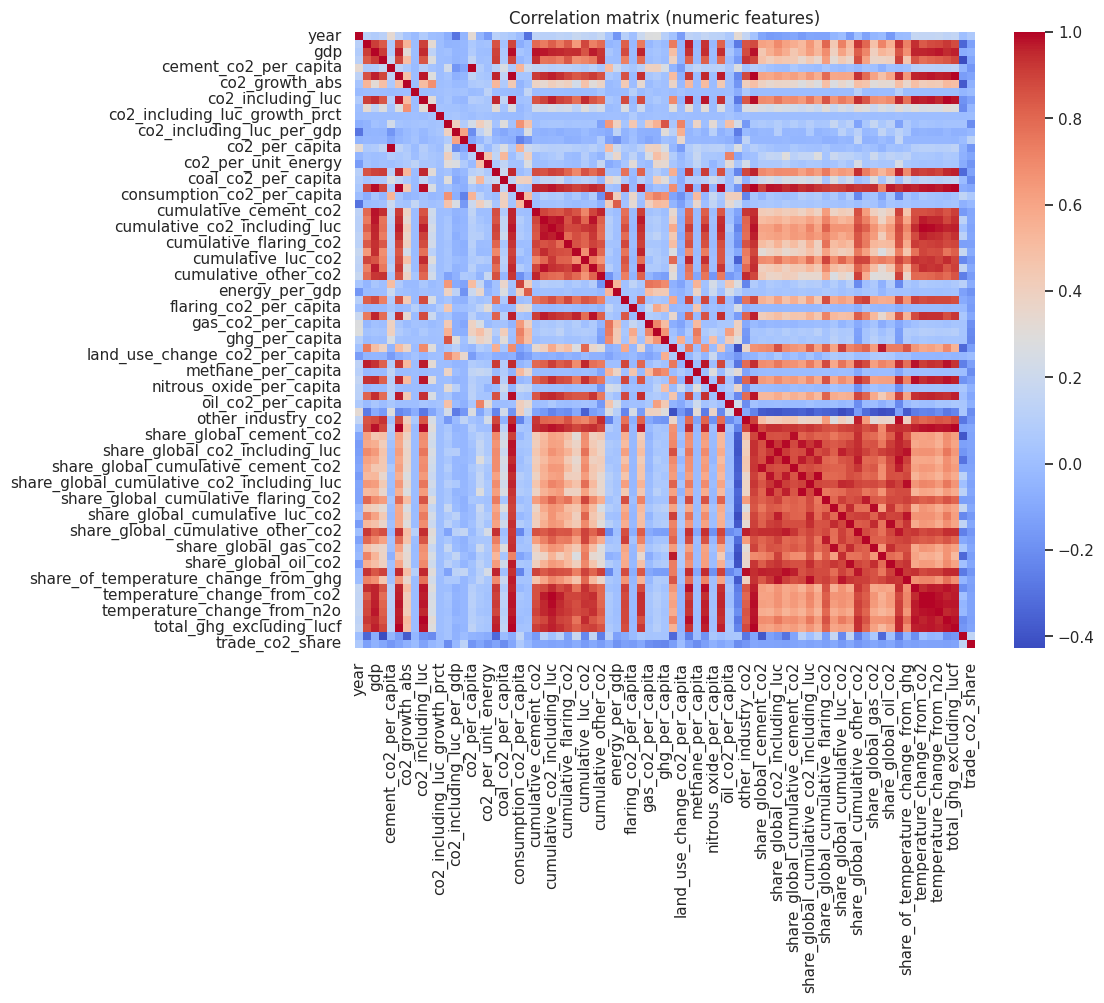

In [71]:
num_cols   =   df.select_dtypes(include=[np.number]).columns.tolist()
if len(num_cols) > 1:
   corr = df[num_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title('Correlation matrix (numeric features)')
plt.show()


In [72]:
cat_cols  =  df.select_dtypes(include=['object',  'category']).columns.tolist()
# Define target_col before using it
if 'CO2_emissions' in df.columns: target_col = 'CO2_emissions'
else:
# try searching for plausible target columns
      candidates = [c for c in df.columns if 'co2' in c.lower() or 'emiss' in c.
lower()]
      target_col = candidates[0] if candidates else df.columns[-1]
      print('Auto-selected target column:', target_col)
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns.tolist()
if c != target_col]


Auto-selected target column: cement_co2


In [73]:
print('Categorical columns:', cat_cols)
print('Numerical columns:', num_cols)

Categorical columns: ['Description', 'Name', 'iso_code']
Numerical columns: ['year', 'population', 'gdp', 'cement_co2_per_capita', 'co2', 'co2_growth_abs', 'co2_growth_prct', 'co2_including_luc', 'co2_including_luc_growth_abs', 'co2_including_luc_growth_prct', 'co2_including_luc_per_capita', 'co2_including_luc_per_gdp', 'co2_including_luc_per_unit_energy', 'co2_per_capita', 'co2_per_gdp', 'co2_per_unit_energy', 'coal_co2', 'coal_co2_per_capita', 'consumption_co2', 'consumption_co2_per_capita', 'consumption_co2_per_gdp', 'cumulative_cement_co2', 'cumulative_co2', 'cumulative_co2_including_luc', 'cumulative_coal_co2', 'cumulative_flaring_co2', 'cumulative_gas_co2', 'cumulative_luc_co2', 'cumulative_oil_co2', 'cumulative_other_co2', 'energy_per_capita', 'energy_per_gdp', 'flaring_co2', 'flaring_co2_per_capita', 'gas_co2', 'gas_co2_per_capita', 'ghg_excluding_lucf_per_capita', 'ghg_per_capita', 'land_use_change_co2', 'land_use_change_co2_per_capita', 'methane', 'methane_per_capita', 'nitro

In [74]:
if 'population' in df.columns:
     df['co2_per_capita'] = df[target_col] / (df['population'].replace({0: np.
nan}))
     num_cols.append('co2_per_capita')


In [75]:
for col in num_cols:
    if (df[col] > 0).all() and df[col].skew() > 1:
        df[col + '_log'] = np.log1p(df[col])
        num_cols.append(col + '_log')


In [76]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


In [77]:
categorical_transformer = Pipeline(steps=[ ('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))
])


In [78]:
preprocessor = ColumnTransformer( transformers=[
('num', numeric_transformer, num_cols), ('cat', categorical_transformer, cat_cols)
],
remainder='drop'
)


In [79]:
all_cols = num_cols + cat_cols
unique_cols = list(set(all_cols))
X = df[unique_cols].copy()
y = df[target_col].copy()


In [80]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=42)


In [81]:
try:
    ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
    cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist()
except Exception:
      cat_feature_names = []
all_feature_names = num_cols + cat_feature_names
feature_names = list(set(all_feature_names))


In [82]:
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)
print('Processed train shape:', X_train_proc.shape)

Processed train shape: (34996, 553)


In [83]:
models = {
'LinearRegression': LinearRegression(), 'Ridge': Ridge(alpha=1.0),
'Lasso': Lasso(alpha=0.01),
'DecisionTree': DecisionTreeRegressor(random_state=42),
'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42), 'GradientBoosting': GradientBoostingRegressor(n_estimators=100,
random_state=42),
'SVR': SVR()
}


In [84]:
if has_xgb:
    models['XGBoost'] = xgb.XGBRegressor(objective='reg:squarederror',
n_estimators=100, random_state=42)


In [85]:
input_shape = X_train_proc.shape[1]

In [86]:
def build_mlp(input_dim):
    model = tf.keras.models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return  model


In [87]:
def to_seq(X):
      return  X.reshape((X.shape[0],  X.shape[1],  1))


In [88]:
X_train_seq = to_seq(X_train_proc.toarray())
X_test_seq = to_seq(X_test_proc.toarray())

In [89]:
cnn = tf.keras.models.Sequential([
     layers.Input(shape=(X_train_seq.shape[1], 1)),
     layers.Conv1D(64, kernel_size=3, activation='relu'),
     layers.Conv1D(32, kernel_size=3, activation='relu'),
     layers.Flatten(),
     layers.Dense(1, activation='linear')
     ])


In [90]:
rf = models['RandomForest']
try:
     importances = rf.feature_importances_
     fi = pd.Series(importances, index=feature_names)
     fi_sorted = fi.sort_values(ascending=False).head(20)
     plt.figure(figsize=(8,6))
     fi_sorted.plot(kind='bar')
     plt.title('Random Forest Top Feature Importances')
     plt.show()
except Exception as e:
     print('Could not compute feature importances:', e)



Could not compute feature importances: This RandomForestRegressor instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.


In [92]:
from  sklearn.inspection  import  partial_dependence, PartialDependenceDisplay
if len(feature_names) >= 1:
    feat_idx = 0
    try:
        # Fit the random forest model
        rf.fit(X_train_proc, y_train)
        display = PartialDependenceDisplay.from_estimator(rf, X_test_proc, [feat_idx],  feature_names=feature_names)
        # Display the plot
        display.figure_.suptitle(f"Partial Dependence Plot for Feature: {feature_names[feat_idx]}")
        plt.show()
    except Exception as e:
        print('PDP failed:', e)

PDP failed: Input y contains NaN.


In [93]:
cnn_preds = cnn.predict(X_test_seq).flatten()

274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step


In [95]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Remove NaN values from y_test and corresponding predictions
valid_indices = ~np.isnan(y_test)
y_test_valid = y_test[valid_indices]
cnn_preds_valid = cnn_preds[valid_indices]

print("NaNs in y_test_valid:", np.isnan(y_test_valid).sum())
print("NaNs in cnn_preds_valid:", np.isnan(cnn_preds_valid).sum())

# Calculate evaluation metrics
mae = mean_absolute_error(y_test_valid, cnn_preds_valid)
mse = mean_squared_error(y_test_valid, cnn_preds_valid)

print(f"CNN Mean Absolute Error: {mae:.4f}")
print(f"CNN Mean Squared Error: {mse:.4f}")

NaNs in y_test_valid: 0
NaNs in cnn_preds_valid: 0
CNN Mean Absolute Error: 8.6924
CNN Mean Squared Error: 3935.1176


In [97]:
y_filled = np.nan_to_num(y_test_valid, nan=0.0)
pred_filled = np.nan_to_num(cnn_preds_valid, nan=0.0)